# Gaussian process regression

In [ ]:
import sys
import os

import numpy as np
import torch
import pandas as pd
import gpytorch

sys.path.insert(0, os.path.abspath(".."))

try:
    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Load data and model

In [ ]:
X = pd.read_csv("../_temp/X.csv").drop(columns="Slurry")
y = pd.read_csv("../_temp/y.csv")
data = pd.concat([X, y], axis=1)

In [ ]:
from scripts.model import load_model, GPR_H, GPR_phi

H_model, H_likelihood, H_scaler = load_model(GPR_H, f"../model/GPR.H.pt", device=device)
phi_model, phi_likelihood, phi_scaler = load_model(
    GPR_phi, f"../model/GPR.phi.pt", device=device
)

H_model.eval()
phi_model.eval();

## Plot

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [ ]:
Rgt_min, Rgt_max = X["Gap_to_thickness_ratio"].min(), X["Gap_to_thickness_ratio"].max()
Ca_min, Ca_max = X["Capillary_number"].min(), X["Capillary_number"].max()
Ct_min, Ct_max = X["Cos_theta"].min(), X["Cos_theta"].max()

N = 50
CHUNK = 4096


def predict(Rgt_flat, Ca_flat, Ct_flat, model, likelihood, scaler):
    """Return predicted mean on a flat array of inputs."""
    X_raw = np.column_stack([Rgt_flat, Ca_flat, Ct_flat])
    X_scaled = torch.tensor(scaler.transform(X_raw), dtype=torch.float32, device=device)
    means = []
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        for i in range(0, len(X_scaled), CHUNK):
            chunk = X_scaled[i : i + CHUNK]
            pred = likelihood(model(chunk))
            means.append(pred.mean.cpu().numpy())
    return np.concatenate(means)

### Box surface plot

In [ ]:
Rgt_1d = np.linspace(Rgt_min, Rgt_max, N)
Ca_1d = np.linspace(Ca_min, Ca_max, N)
Ct_1d = np.linspace(Ct_min, Ct_max, N)

Rgt_Ca_A, Rgt_Ca_B = np.meshgrid(Rgt_1d, Ca_1d, indexing="ij")
Ca_Ct_A, Ca_Ct_B = np.meshgrid(Ca_1d, Ct_1d, indexing="ij")
Rgt_Ct_A, Rgt_Ct_B = np.meshgrid(Rgt_1d, Ct_1d, indexing="ij")


def _get_face_val(arg1, arg2, arg3, zdir, offset):
    if zdir == "z":
        return arg3
    elif zdir == "x":
        return arg1
    else:
        return arg2

#### H

In [ ]:
H_faces = []
for ct in [Ct_min, Ct_max]:
    H = predict(
        Rgt_Ca_A.ravel(),
        Rgt_Ca_B.ravel(),
        np.full(N * N, ct),
        H_model,
        H_likelihood,
        H_scaler,
    ).reshape(N, N)
    H_faces.append((Rgt_Ca_A, Rgt_Ca_B, H, "z", ct))
for rgt in [Rgt_min, Rgt_max]:
    H = predict(
        np.full(N * N, rgt),
        Ca_Ct_A.ravel(),
        Ca_Ct_B.ravel(),
        H_model,
        H_likelihood,
        H_scaler,
    ).reshape(N, N)
    H_faces.append((H, Ca_Ct_A, Ca_Ct_B, "x", rgt))
for ca in [Ca_min, Ca_max]:
    H = predict(
        Rgt_Ct_A.ravel(),
        np.full(N * N, ca),
        Rgt_Ct_B.ravel(),
        H_model,
        H_likelihood,
        H_scaler,
    ).reshape(N, N)
    H_faces.append((Rgt_Ct_A, H, Rgt_Ct_B, "y", ca))

In [ ]:
H_all = np.concatenate([_get_face_val(*f).ravel() for f in H_faces])
vmin, vmax = H_all.min(), H_all.max()

n_color = 15
coolwarm = plt.cm.coolwarm
colors = [coolwarm(i / (n_color - 1)) for i in range(n_color)]
cmap = mcolors.ListedColormap(colors)
levels = np.linspace(vmin, vmax, n_color + 1)
norm = mcolors.BoundaryNorm(levels, cmap.N)

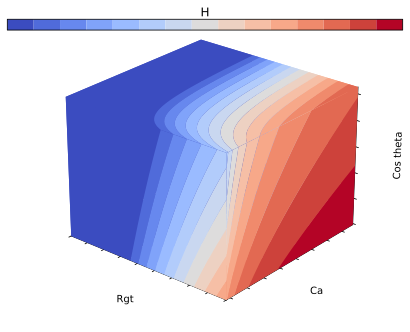

In [ ]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_axes([0.02, 0.10, 0.82, 0.88], projection="3d")

for arg1, arg2, arg3, zdir, offset in H_faces:
    ax.contourf(
        arg1,
        arg2,
        arg3,
        zdir=zdir,
        offset=offset,
        levels=levels,
        cmap=cmap,
        norm=norm,
    )

ax.set_xlim(Rgt_min, Rgt_max)
ax.set_ylim(Ca_min, Ca_max)
ax.set_zlim(Ct_min, Ct_max)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.set_xlabel("Rgt")
ax.set_ylabel("Ca")
ax.set_zlabel("Cos theta")
ax.view_init(elev=25, azim=-50)

# Hide background panes and grid
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("none")
ax.yaxis.pane.set_edgecolor("none")
ax.zaxis.pane.set_edgecolor("none")
ax.grid(False)

# Colorbar (horizontal at top)
cbar_ax = fig.add_axes([0.15, 0.92, 0.55, 0.03])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
cb = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", ticks=[])
cbar_ax.set_title("H", pad=3)
plt.show()

#### phi

In [ ]:
phi_faces = []
for ct in [Ct_min, Ct_max]:
    phi = predict(
        Rgt_Ca_A.ravel(),
        Rgt_Ca_B.ravel(),
        np.full(N * N, ct),
        phi_model,
        phi_likelihood,
        phi_scaler,
    ).reshape(N, N)
    phi_faces.append((Rgt_Ca_A, Rgt_Ca_B, phi, "z", ct))
for rgt in [Rgt_min, Rgt_max]:
    phi = predict(
        np.full(N * N, rgt),
        Ca_Ct_A.ravel(),
        Ca_Ct_B.ravel(),
        phi_model,
        phi_likelihood,
        phi_scaler,
    ).reshape(N, N)
    phi_faces.append((phi, Ca_Ct_A, Ca_Ct_B, "x", rgt))
for ca in [Ca_min, Ca_max]:
    phi = predict(
        Rgt_Ct_A.ravel(),
        np.full(N * N, ca),
        Rgt_Ct_B.ravel(),
        phi_model,
        phi_likelihood,
        phi_scaler,
    ).reshape(N, N)
    phi_faces.append((Rgt_Ct_A, phi, Rgt_Ct_B, "y", ca))

In [ ]:
phi_all = np.concatenate([_get_face_val(*f).ravel() for f in phi_faces])
vmin, vmax = phi_all.min(), phi_all.max()

n_color = 15
coolwarm = plt.cm.coolwarm
colors = [coolwarm(i / (n_color - 1)) for i in range(n_color)]
cmap = mcolors.ListedColormap(colors)
levels = np.linspace(vmin, vmax, n_color + 1)
norm = mcolors.BoundaryNorm(levels, cmap.N)

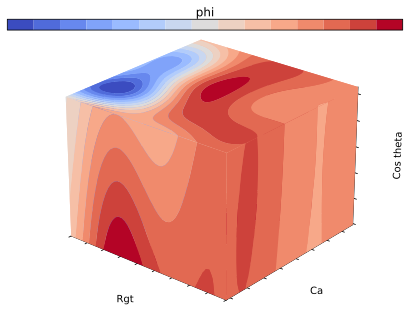

In [ ]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_axes([0.02, 0.10, 0.82, 0.88], projection="3d")

for arg1, arg2, arg3, zdir, offset in phi_faces:
    ax.contourf(
        arg1,
        arg2,
        arg3,
        zdir=zdir,
        offset=offset,
        levels=levels,
        cmap=cmap,
        norm=norm,
    )

ax.set_xlim(Rgt_min, Rgt_max)
ax.set_ylim(Ca_min, Ca_max)
ax.set_zlim(Ct_min, Ct_max)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.set_xlabel("Rgt")
ax.set_ylabel("Ca")
ax.set_zlabel("Cos theta")
ax.view_init(elev=25, azim=-50)

# Hide background panes and grid
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("none")
ax.yaxis.pane.set_edgecolor("none")
ax.zaxis.pane.set_edgecolor("none")
ax.grid(False)

# Colorbar (horizontal at top)
cbar_ax = fig.add_axes([0.15, 0.92, 0.55, 0.03])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
cb = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal", ticks=[])
cbar_ax.set_title("phi", pad=3)
plt.show()